# Requirements

## Logging

In [1]:
import logging
import sys

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler(stream=sys.stdout)],
    force=True,
)

In [2]:
logger = logging.getLogger(__name__)

## Imports

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from netbalance.configs import OptimizerConfig
from netbalance.data.bipartite_graph_data import BGData, BGTrainTestSpliter
from netbalance.features.hmdad import HMDADDataset
from netbalance.models.degree_ratio import DegreeRatioHandlerFactory
from netbalance.optimization import BGCTester
from netbalance.optimization.degree_ratio import DegreeRatioTrainer

2024-12-15 22:01:02,172 [INFO] NumExpr defaulting to 8 threads.


## Notebook Configs

In [4]:
model_name = "avg_degree_ratio"
dataset = "hmdad"
fontname = "Helvetica"
save_figs = False
negative_ratio = 1.0

ds = HMDADDataset()

In [5]:
c_pos = "#a2d2ff"
c_neg = "#ffafcc"
c_pos_test = "#4ba8ff"
c_neg_test = "#ff5392"
c_hist = "#a2d2ff"

## Matplotlib Configs

In [6]:
import matplotlib as mpl

mpl.rc("font", family=fontname)

# Configs

In [7]:
optimizer_config = OptimizerConfig()

# Data

In [8]:
associations = ds.get_associations(with_negatives=True)

2024-12-15 22:01:02,375 [INFO] Cluster A and Cluster B sizes: 292, 39
2024-12-15 22:01:02,375 [INFO] Positive associations count: 450.0
2024-12-15 22:01:02,382 [INFO] Total samples generated: 11388


In [9]:
associations.shape

(11388, 3)

In [10]:
associations.sum(axis=0)[2]

450

# Model

In [11]:
factory = DegreeRatioHandlerFactory(
    a_node_ids=list(set(associations[:, 0])),
    b_node_ids=list(set(associations[:, 1])),
    use_a=True,
    use_b=True,
    reduction="weighted_mean",
)

model_handler = factory.create_handler()

In [12]:
trainer = DegreeRatioTrainer()
tester = BGCTester()
spliter = BGTrainTestSpliter(
    k=5,
    data=BGData(
        associations, ds.get_cluster_a_node_names(), ds.get_cluster_b_node_names()
    ),
    seed=42,
    train_balance=False,
    test_balance=False,
)

In [13]:
train_data, test_data = spliter.split(1)

In [14]:
train_data.associations.shape, test_data.associations.shape

((9111, 3), (2277, 3))

In [15]:
train_data.associations.sum(axis=0)[2], test_data.associations.sum(axis=0)[2]

(356, 94)

In [16]:
train_result = trainer.train(
    model_handler=model_handler, data=train_data, config=optimizer_config
)

2024-12-15 22:01:02,570 [INFO] #################### Training the model ####################


In [17]:
test_result = tester.test(
    model_handler=model_handler, data=test_data, config=optimizer_config
)

2024-12-15 22:01:02,923 [INFO] #################### Testing the model #####################
2024-12-15 22:01:02,930 [INFO] Predictions generated.
2024-12-15 22:01:03,499 [INFO] Model evaluation complete.


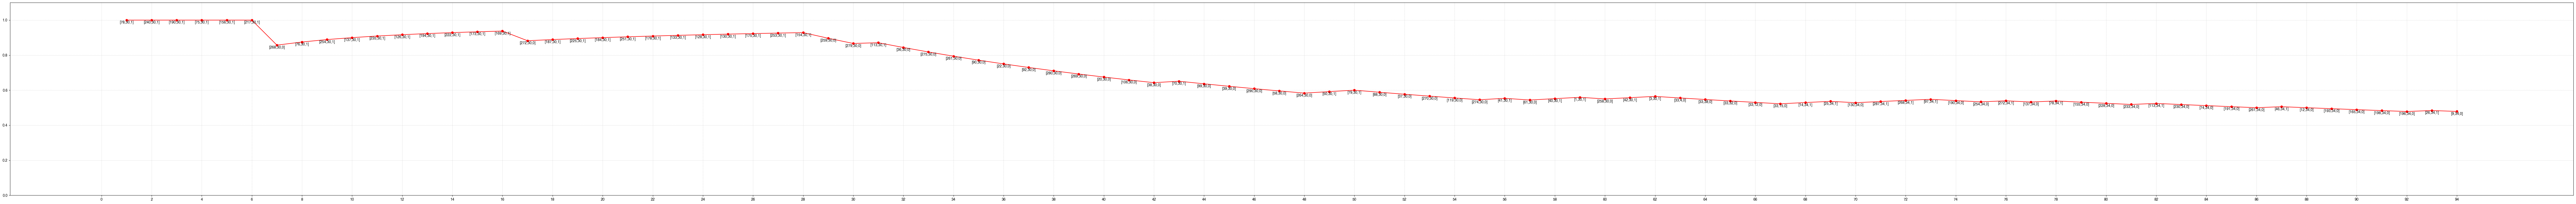

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(100, 8))

# Plot the data
ax.plot(
    test_result.hit_k_list,
    test_result.hit_k_accuracy_list,
    marker="o",
    linestyle="-",
    color="r",
    label="Top-k Accuracy",
)

# Add gridlines
ax.grid(visible=True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

# Annotate specific points for clarity
for i, (x, y) in enumerate(
    zip(test_result.hit_k_list, test_result.hit_k_accuracy_list)
):
    ax.annotate(
        f"[{int(test_result.sorted_edges[i, 0])},{int(test_result.sorted_edges[i, 1])},{int(test_result.sorted_edges[i, 2])}]",
        (x, y - 0.03),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=10,
    )

x_ticks = np.arange(0, max(test_result.hit_k_list) + 2, 2)
ax.set_xticks(x_ticks)
ax.set_ylim(0, 1.1)


fig.tight_layout()

In [19]:
test_data.associations.sum(axis=0)[2] / test_data.associations.shape[0]

0.041282389108476064

In [20]:
test_data.cluster_b_node_names[test_result.sorted_edges[0, 1]]

'Type 1 diabetes'

In [21]:
b = test_data.associations[
    test_data.associations[:, 1] == test_result.sorted_edges[0, 1], :
]

In [22]:
b.shape

(62, 3)

In [23]:
b[:, 2].sum()

35

In [24]:
test_result.hit_k_accuracy_list[-1]

0.4787234042553192